In [5]:
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import rasterio

# Save land/water masks for upsampled imagery

1. **Example `fn`** — reference layout from your SDS pipeline (`pred_masks/ndwi_otsu/...`).
2. **Inspect cell** — load one `.npy` and plot.
3. **Batch cells** — walk `data/sat_images/<site>/<bilinear|bicubic>/...`, compute **NDWI + Otsu**, save **bool** masks (`True` = land, same as class 1) under **this repo**: `data/image_masks/pred_images/ndwi_otsu_bilinear|bicubic/<site>/<sat>/`.

In [3]:
# example of current saved bin mask:
fn = r'C:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\image_masks\pred_masks\ndwi_otsu\australianarrabeen\L5\australianarrabeen-L5_19870522_089083_pred.npy'

path: C:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\image_masks\pred_masks\ndwi_otsu\australianarrabeen\L5\australianarrabeen-L5_19870522_089083_pred.npy
ndim: 2
shape: (418, 160)
dtype: bool
size (elements): 66880
nbytes: 66880
min (finite): 0.0
max (finite): 1.0
mean (finite): 0.4249102870813397
unique values: [False  True]
value counts: {0.0: 38462, 1.0: 28418}


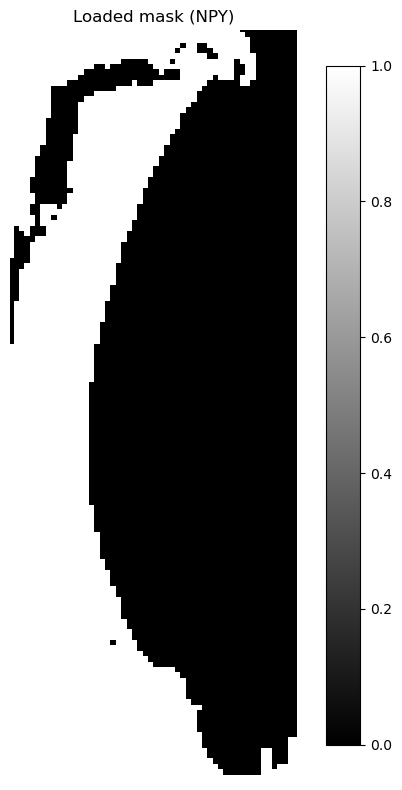

In [6]:
arr = np.load(fn, mmap_mode=None)
arr = np.squeeze(arr)

print("path:", fn)
print("ndim:", arr.ndim)
print("shape:", arr.shape)
print("dtype:", arr.dtype)
print("size (elements):", arr.size)
print("nbytes:", arr.nbytes)

finite = np.isfinite(arr)
if finite.any():
    sub = arr[finite]
    print("min (finite):", float(np.min(sub)))
    print("max (finite):", float(np.max(sub)))
    print("mean (finite):", float(np.mean(sub)))
else:
    print("no finite values")

uniq = np.unique(arr)
if uniq.size <= 32:
    print("unique values:", uniq)
    print("value counts:", {float(v): int(np.sum(arr == v)) for v in uniq})
else:
    print(f"unique count: {uniq.size} (not listing)")

if arr.ndim == 2:
    arr_plot = arr
elif arr.ndim == 3:
    print("3D array after squeeze; plotting arr[0] for display.")
    arr_plot = arr[0]
else:
    raise ValueError(f"Cannot plot as 2D image: shape {arr.shape}")

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(arr_plot, cmap="gray", interpolation="nearest")
ax.set_title("Loaded mask (NPY)")
ax.set_axis_off()
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [7]:
# Root of this repo (notebook assumed run from repo root).
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()

# Upsampled GeoTIFFs from convert_sites_batch / convert_site_tiffs.
SAT_IMAGES_ROOT = PROJECT_ROOT / "data" / "sat_images"

# Masks go here (not under SDS_performance_analysis). Mirrors:
#   <other_project>/data/image_masks/pred_masks/ndwi_otsu/<site>/<sat>/<site>-<stem>_pred.npy
# but uses pred_images and ndwi_otsu_<bilinear|bicubic>.
MASKS_ROOT = PROJECT_ROOT / "data" / "image_masks" / "pred_images"

print("PROJECT_ROOT     :", PROJECT_ROOT.resolve())
print("SAT_IMAGES_ROOT  :", SAT_IMAGES_ROOT.resolve())
print("MASKS_ROOT       :", MASKS_ROOT.resolve())

try:
    _ex = Path(fn)
    print("reference mask (from fn):", _ex.name)
    print("reference parent trail   :", _ex.parts[-4:])
except NameError:
    pass

PROJECT_ROOT     : C:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution
SAT_IMAGES_ROOT  : C:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\sat_images
MASKS_ROOT       : C:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\image_masks\pred_images
reference mask (from fn): australianarrabeen-L5_19870522_089083_pred.npy
reference parent trail   : ('ndwi_otsu', 'australianarrabeen', 'L5', 'australianarrabeen-L5_19870522_089083_pred.npy')


In [8]:
def _normalize_name(name: str) -> str:
    return "".join(ch for ch in name.lower() if ch.isalnum())


def _band_aliases() -> Dict[str, Tuple[str, ...]]:
    return {
        "blue": ("blue", "b", "band2", "b2"),
        "green": ("green", "g", "band3", "b3"),
        "red": ("red", "r", "band4", "b4"),
        "nir": ("nir", "nearinfrared", "nearir", "band5", "b5", "nir08", "nir1"),
    }


def _extract_band_names(src: rasterio.io.DatasetReader) -> List[str]:
    names: List[str] = []
    for i in range(1, src.count + 1):
        desc = src.descriptions[i - 1] if src.descriptions else None
        tags = src.tags(i)
        tag_name = tags.get("name") or tags.get("band_name") or tags.get("long_name")
        chosen = (desc or tag_name or f"band{i}").strip()
        names.append(chosen)
    return names


def _find_band_index(band_names: List[str], key: str) -> int:
    aliases = tuple(_normalize_name(a) for a in _band_aliases()[key])
    normalized = [_normalize_name(n) for n in band_names]

    for idx, n in enumerate(normalized):
        if n in aliases:
            return idx

    for idx, n in enumerate(normalized):
        if any(a in n for a in aliases):
            return idx

    raise ValueError(f"Could not find band '{key}' in names: {band_names}")


def _safe_index(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    denom = a + b
    out = (a - b) / (denom + eps)
    return np.clip(out, -1.0, 1.0)


def otsu_threshold(img: np.ndarray, bins: int = 256) -> float:
    """Same histogram Otsu as water_index_hr_comparison.ipynb."""
    vals = img[np.isfinite(img)].ravel()
    if vals.size == 0:
        return 0.0

    vmin, vmax = float(vals.min()), float(vals.max())
    if vmax <= vmin:
        return vmin

    hist, edges = np.histogram(vals, bins=bins, range=(vmin, vmax))
    hist = hist.astype(np.float64)
    centers = (edges[:-1] + edges[1:]) / 2.0

    w0 = np.cumsum(hist)
    w1 = np.cumsum(hist[::-1])[::-1]

    mu = np.cumsum(hist * centers)
    mu_t = mu[-1]

    eps = 1e-12
    mu0 = mu / (w0 + eps)
    mu1 = (mu_t - mu) / (w1 + eps)

    sigma_b2 = w0 * w1 * (mu0 - mu1) ** 2
    idx = int(np.nanargmax(sigma_b2))
    return float(centers[idx])


def ndwi_otsu_land_mask(data: np.ndarray, band_names: List[str]) -> np.ndarray:
    """Land = True (1): finite pixels with NDWI <= Otsu threshold (water if NDWI > T)."""
    g = data[_find_band_index(band_names, "green")].astype(np.float32)
    n = data[_find_band_index(band_names, "nir")].astype(np.float32)
    ndwi = _safe_index(g, n)
    t = otsu_threshold(ndwi)
    land = np.isfinite(ndwi) & (ndwi <= t)
    return land


def iter_hr_multiband_tiffs(sat_root: Path) -> Iterable[Tuple[Path, str, str]]:
    """Yield (tif_path, site_name, technique) for bilinear/bicubic trees."""
    if not sat_root.is_dir():
        return
    for site_dir in sorted(p for p in sat_root.iterdir() if p.is_dir()):
        site = site_dir.name
        for technique in ("bilinear", "bicubic"):
            tech_dir = site_dir / technique
            if not tech_dir.is_dir():
                continue
            for pattern in ("*.tif", "*.tiff"):
                for tif in sorted(tech_dir.rglob(pattern)):
                    yield tif, site, technique


def mask_out_path(
    masks_root: Path, technique: str, site: str, sat_folder: str, tif_stem: str
) -> Path:
    method_dir = f"ndwi_otsu_{technique}"
    fname = f"{site}-{tif_stem}_pred.npy"
    return masks_root / method_dir / site / sat_folder / fname


def parse_sat_folder(tif_path: Path, site: str, technique: str) -> str:
    rel = tif_path.relative_to(SAT_IMAGES_ROOT / site / technique)
    parts = rel.parts
    if len(parts) >= 2:
        return parts[0]
    stem = tif_path.stem
    if "_" in stem:
        return stem.split("_", 1)[0]
    return "unknown"

In [9]:
# Batch: NDWI (Green, NIR) + Otsu → bool land mask (True = land), saved next to this repo's data tree.
RUN_BATCH = True
OVERWRITE = False
MAX_FILES = None  # set to int (e.g. 10) to only process the first N TIFFs

if not RUN_BATCH:
    print("Set RUN_BATCH = True to write masks.")
else:
    written = 0
    skipped_existing = 0
    skipped_singleband = 0
    errors = 0

    for i, (tif_path, site, technique) in enumerate(
        iter_hr_multiband_tiffs(SAT_IMAGES_ROOT)
    ):
        if MAX_FILES is not None and i >= MAX_FILES:
            break

        sat_folder = parse_sat_folder(tif_path, site, technique)
        out_path = mask_out_path(
            MASKS_ROOT, technique, site, sat_folder, tif_path.stem
        )

        if out_path.exists() and not OVERWRITE:
            skipped_existing += 1
            continue

        try:
            with rasterio.open(tif_path) as src:
                if src.count < 2:
                    skipped_singleband += 1
                    continue
                data = src.read().astype(np.float32)
                names = _extract_band_names(src)
            land = ndwi_otsu_land_mask(data, names)
        except Exception as exc:
            errors += 1
            warnings.warn(f"{tif_path}: {exc}", stacklevel=2)
            continue

        out_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(out_path, land.astype(bool))
        written += 1
        if written % 25 == 0:
            print("saved", written, "…")

    print(
        "written:", written,
        "| skipped (existing):", skipped_existing,
        "| skipped (single-band):", skipped_singleband,
        "| errors:", errors,
    )

saved 25 …
saved 50 …
saved 75 …
saved 100 …
saved 125 …
saved 150 …
saved 175 …
saved 200 …
saved 225 …
saved 250 …
saved 275 …
saved 300 …
saved 325 …
saved 350 …
saved 375 …
saved 400 …
saved 425 …
saved 450 …
saved 475 …
saved 500 …
saved 525 …
saved 550 …
saved 575 …
saved 600 …
saved 625 …
saved 650 …
saved 675 …
saved 700 …
saved 725 …
saved 750 …
saved 775 …
saved 800 …
saved 825 …
saved 850 …
saved 875 …
saved 900 …
saved 925 …
saved 950 …
saved 975 …
saved 1000 …
saved 1025 …
saved 1050 …
saved 1075 …
saved 1100 …
saved 1125 …
saved 1150 …
saved 1175 …
saved 1200 …
saved 1225 …
saved 1250 …
saved 1275 …
saved 1300 …
saved 1325 …
saved 1350 …
saved 1375 …
saved 1400 …
saved 1425 …
saved 1450 …
saved 1475 …
saved 1500 …
saved 1525 …
saved 1550 …
saved 1575 …
saved 1600 …
saved 1625 …
saved 1650 …
saved 1675 …
saved 1700 …
saved 1725 …
saved 1750 …
saved 1775 …
saved 1800 …
saved 1825 …
saved 1850 …
saved 1875 …
saved 1900 …
saved 1925 …
saved 1950 …
saved 1975 …
saved 2000 …
sa

c:\Users\jnicolow\AppData\Local\miniconda3\envs\geo_tide\Lib\site-packages\IPython\core\interactiveshell.py:3699: UserWarning: c:\Users\jnicolow\Documents\research\CRC\change_tiff_resolution\data\sat_images\northcarolinaduck\bicubic\L7\L7_20050612_013035.tif: Too many bins for data range. Cannot create 256 finite-sized bins.
  exec(code_obj, self.user_global_ns, self.user_ns)


saved 3900 …
saved 3925 …
saved 3950 …
saved 3975 …
saved 4000 …
saved 4025 …
saved 4050 …
saved 4075 …
saved 4100 …
saved 4125 …
saved 4150 …
saved 4175 …
saved 4200 …
saved 4225 …
saved 4250 …
saved 4275 …
saved 4300 …
saved 4325 …
saved 4350 …
saved 4375 …
saved 4400 …
saved 4425 …
saved 4450 …
saved 4475 …
saved 4500 …
saved 4525 …
written: 4545 | skipped (existing): 0 | skipped (single-band): 0 | errors: 1
